In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import tensorflow as tf
from tensorflow import keras
#import keras.api._v2.keras as keras
from keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from patchify import patchify
from PIL import Image
import segmentation_models as sm
from keras.metrics import MeanIoU
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.utils import to_categorical, load_img
from sklearn.model_selection import train_test_split
from keras.models import load_model
from tqdm import tqdm
import random
import pickle
from keras.callbacks import Callback, ModelCheckpoint, EarlyStopping
from keras.optimizers import SGD, Adam 


In [7]:
sm.set_framework('tf.keras')

In [8]:
def data_loader(folder_dir):
    image_dataset = []
    for images in os.listdir(folder_dir):
        image=cv2.imread(folder_dir+'/'+images, 1)
        image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image=cv2.resize(image, (128, 128))
        image=np.array(image)
        image_dataset.append(image)
    return image_dataset

In [9]:
image_dataset=data_loader("E:/Offroad database/Rest of the files/Training Images and Labels/images")

In [10]:
mask_dataset=data_loader("E:/Offroad database/Rest of the files/Training Images and Labels/labels")

In [11]:
image_dataset=np.array(image_dataset)
mask_dataset=np.array(mask_dataset)

In [12]:
mask_dataset.shape

(931, 128, 128, 3)

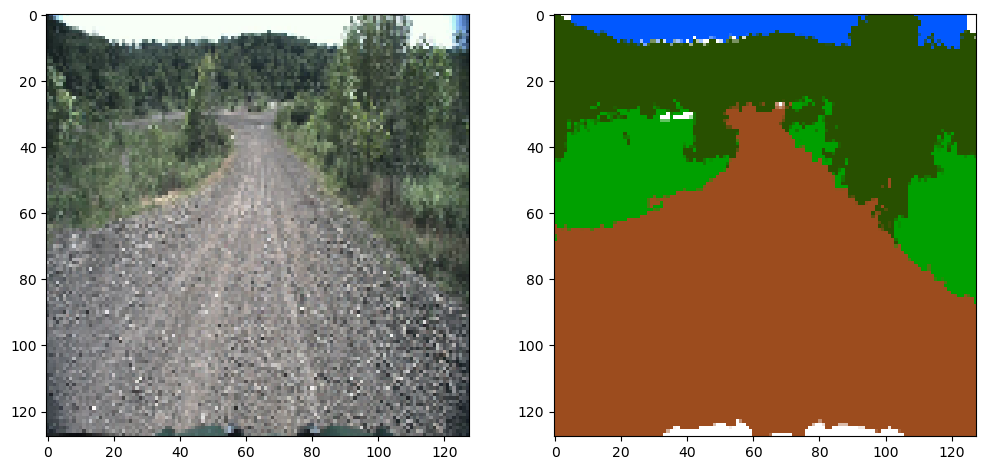

In [13]:
image_number=random.randint(0,len(image_dataset))
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(image_dataset[image_number])
plt.subplot(122)
plt.imshow(mask_dataset[image_number])
plt.show()

In [14]:
mask_labels=pd.read_csv("E:/Offroad database/yamaha_seg/class_dict.csv")

In [15]:
mask_labels

,name,r,g,b
0,unlabeled,0,0,0
1,background,255,255,255
2,high_vegetation,40,80,0
3,traversable_grass,128,255,0
4,smooth_trail,178,176,153
5,obstacle,255,0,0
6,sky,1,88,255
7,rough_trail,156,76,30
8,puddle,255,0,128
9,non_traversable_low_vegetation,0,160,0


In [16]:
mask_labels.shape

(10, 4)

In [17]:
mask_labels.shape[0]

10

In [18]:
def rgb_to_labels(img, mask_labels):
    label_seg=np.zeros(img.shape,dtype=np.uint8)
    for i in range(mask_labels.shape[0]):
        label_seg[np.all(img==list(mask_labels.iloc[i,[1,2,3]]), axis=-1)]=i
    label_seg=label_seg[:,:,0]
    return label_seg

In [19]:
labels = []
for i in range(mask_dataset.shape[0]):
    label = rgb_to_labels(mask_dataset[i], mask_labels)
    labels.append(label)

In [20]:
labels=np.array(labels)
labels=np.expand_dims(labels, axis=3)

Unique labels in label dataset are:  [0 1 2 3 4 5 6 7 8 9]


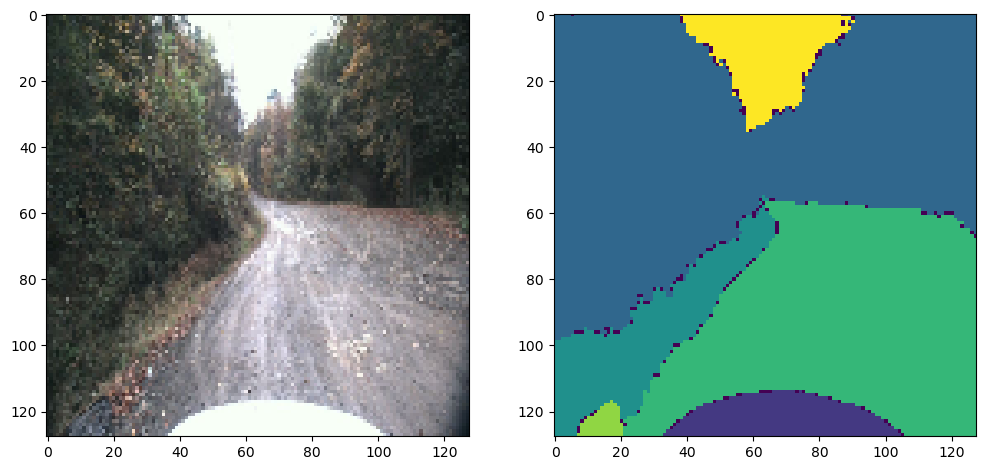

In [21]:
print("Unique labels in label dataset are: ", np.unique(labels))

image_number=random.randint(0,len(image_dataset))
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(image_dataset[image_number])
plt.subplot(122)
plt.imshow(labels[image_number][:,:,0])
plt.show()

In [22]:
n_classes = len(np.unique(labels))
labels_cat=to_categorical(labels, num_classes=n_classes)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(image_dataset, labels_cat, test_size = 0.2, random_state =42)

In [24]:
BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)

In [25]:
X_train_prepr = preprocess_input(X_train)
X_test_prepr = preprocess_input(X_test)

In [26]:
model_resnet_backbone = sm.Unet(BACKBONE, encoder_weights='imagenet', classes=n_classes, activation='softmax')

In [27]:
metrics=['accuracy']
model_resnet_backbone.compile(optimizer='adam', loss='categorical_crossentropy', metrics=metrics)

In [28]:
model_resnet_backbone.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 data (InputLayer)              [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 bn_data (BatchNormalization)   (None, None, None,   9           ['data[0][0]']                   
                                3)                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, None, None,   0          ['bn_data[0][0]']                
                                3)                                                          

In [29]:
history = model_resnet_backbone.fit(X_train_prepr, y_train, batch_size=16, epochs=100, verbose=1, validation_data=(X_test_prepr, y_test))

Epoch 1/100
47/47 [==============================] - 541s 11s/step - loss: 1.2590 - accuracy: 0.5898 - val_loss: 6.8689 - val_accuracy: 0.2781
Epoch 2/100
47/47 [==============================] - 551s 12s/step - loss: 0.8605 - accuracy: 0.6987 - val_loss: 5.6887 - val_accuracy: 0.5339
Epoch 3/100
47/47 [==============================] - 541s 11s/step - loss: 0.7520 - accuracy: 0.7411 - val_loss: 1.0361 - val_accuracy: 0.6867
Epoch 4/100
47/47 [==============================] - 551s 12s/step - loss: 0.7225 - accuracy: 0.7493 - val_loss: 0.9763 - val_accuracy: 0.6910
Epoch 5/100
47/47 [==============================] - 543s 12s/step - loss: 0.7105 - accuracy: 0.7594 - val_loss: 1.0363 - val_accuracy: 0.7242
Epoch 6/100
47/47 [==============================] - 545s 12s/step - loss: 0.6802 - accuracy: 0.7673 - val_loss: 0.8372 - val_accuracy: 0.7266
Epoch 7/100
47/47 [==============================] - 542s 12s/step - loss: 0.6497 - accuracy: 0.7833 - val_loss: 0.7790 - val_accuracy: 0.7164

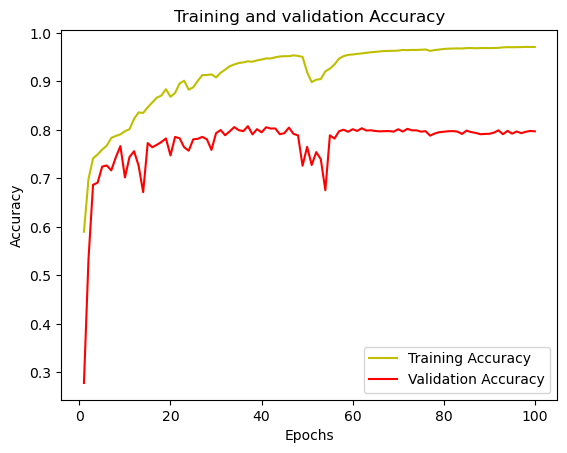

In [30]:
history = history
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, 'y', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [31]:
model_resnet_backbone.save("semantic_yamaha_augmented.h5")

In [32]:
model = load_model('E:/Offroad database/yamaha_seg/semantic_yamaha_augmented.h5')

In [33]:
y_pred=model.predict(X_test)
y_pred_argmax=np.argmax(y_pred, axis=3)
y_test_argmax=np.argmax(y_test, axis=3)

6/6 [==============================] - 3s 275ms/step


In [34]:
test_img_number = random.randint(0, len(X_test))
test_img = X_test[test_img_number]
ground_truth=y_test_argmax[test_img_number]
#print(y_test)
#print(ground_truth)
#test_img_norm=test_img[:,:,0][:,:,None]
test_img_input=np.expand_dims(test_img, 0)
prediction = (model.predict(test_img_input))
predicted_img=np.argmax(prediction, axis=3)[0,:,:]

1/1 [==============================] - 0s 205ms/step


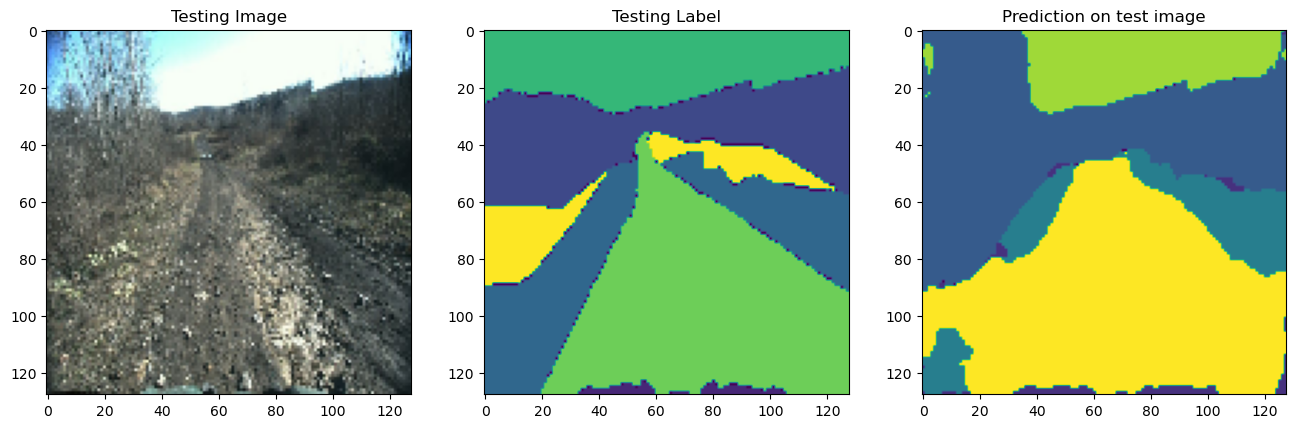

In [35]:
plt.figure(figsize=(16, 12))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img)
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth)
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(predicted_img)
plt.show()

In [36]:
predicted_color_img = np.zeros((predicted_img.shape[0], predicted_img.shape[1], 3), dtype=np.uint8)

colormap = {}
for index, row in mask_labels.iterrows():
    class_index = index  # Class index from the DataFrame
    rgb_color = [row.iloc[1], row.iloc[2], row.iloc[3]]  # RGB color values from the DataFrame
    colormap[class_index] = rgb_color

for class_index, rgb_color in colormap.items():
    predicted_color_img[predicted_img == class_index] = rgb_color

In [37]:
predicted_color_img

array([[[ 40,  80,   0],
        [ 40,  80,   0],
        [ 40,  80,   0],
        ...,
        [  1,  88, 255],
        [  1,  88, 255],
        [255, 255, 255]],

       [[ 40,  80,   0],
        [ 40,  80,   0],
        [ 40,  80,   0],
        ...,
        [  1,  88, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 40,  80,   0],
        [ 40,  80,   0],
        [ 40,  80,   0],
        ...,
        [  1,  88, 255],
        [ 40,  80,   0],
        [ 40,  80,   0]],

       ...,

       [[128, 255,   0],
        [128, 255,   0],
        [128, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[128, 255,   0],
        [128, 255,   0],
        [128, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [128, 255,   0],
        [128, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

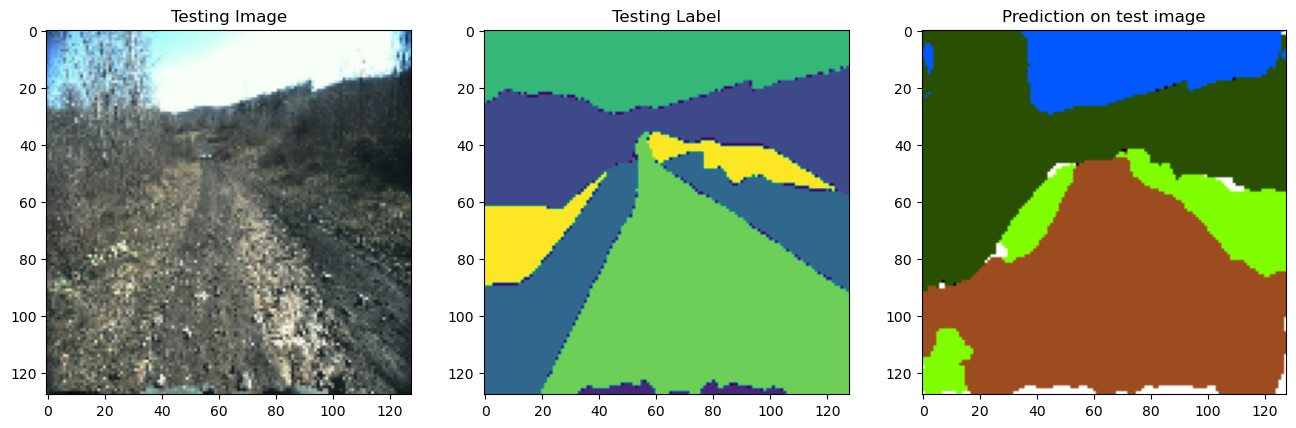

In [38]:
plt.figure(figsize=(16, 12))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img)
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth)
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(predicted_color_img)
plt.show()

In [39]:
validation_img=cv2.imread('E:/Offroad database/yamaha_seg/yamaha_v0/valid/iid000856/rgb.jpg')
validation_img=cv2.cvtColor(validation_img, cv2.COLOR_BGR2RGB)
validation_img=cv2.resize(validation_img, (128,128))
validation_img=np.array(validation_img)

error: OpenCV(4.8.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:182: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


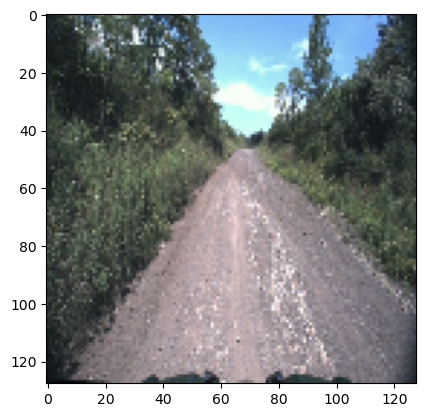

In [ ]:
plt.imshow(validation_img)

In [ ]:
validation_label=cv2.imread('E:/Offroad database/yamaha_seg/yamaha_v0/valid/iid000856/labels.png')
validation_label=cv2.cvtColor(validation_label, cv2.COLOR_BGR2RGB)
validation_label=cv2.resize(validation_label, (128,128))
validation_label=np.array(validation_label)

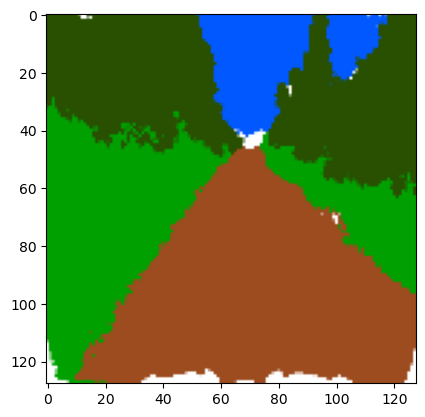

In [ ]:
plt.imshow(validation_label)

In [ ]:
validation_img=np.expand_dims(validation_img, 0)
prediction=model.predict(validation_img)
predicted_img=np.argmax(prediction, axis=3)[0,:,:]


1/1 [==============================] - 0s 124ms/step


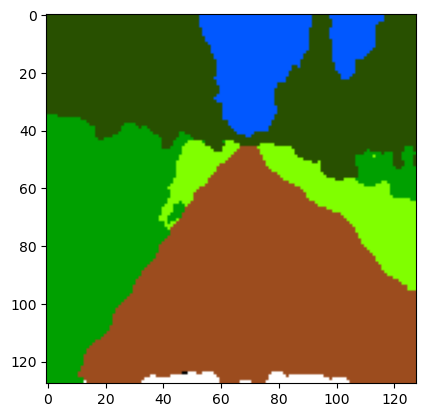

In [ ]:
predicted_color_img = np.zeros((predicted_img.shape[0], predicted_img.shape[1], 3), dtype=np.uint8)

colormap = {}
for index, row in mask_labels.iterrows():
    class_index = index  # Class index from the DataFrame
    rgb_color = [row.iloc[1], row.iloc[2], row.iloc[3]]  # RGB color values from the DataFrame
    colormap[class_index] = rgb_color

for class_index, rgb_color in colormap.items():
    predicted_color_img[predicted_img == class_index] = rgb_color
plt.imshow(predicted_color_img)

In [ ]:
video_path='E:/Offroad database/yamaha_seg/Unreal environment/video.mp4'
cap=cv2.VideoCapture(video_path)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,6))
#plt.ion()

while True:
    ret, validation_img1=cap.read()
    if not ret:
        print("End of video")
        break

    validation_img=cv2.cvtColor(validation_img1, cv2.COLOR_BGR2RGB)
    validation_img=cv2.resize(validation_img, (128,128))
    validation_img=np.array(validation_img)
    validation_img=np.expand_dims(validation_img, 0)
    prediction=model.predict(validation_img)
    predicted_img=np.argmax(prediction, axis=3)[0,:,:]
    
    predicted_color_img = np.zeros((predicted_img.shape[0], predicted_img.shape[1], 3), dtype=np.uint8)

    colormap = {}
    for index, row in mask_labels.iterrows():
        class_index = index  # Class index from the DataFrame
        rgb_color = [row.iloc[1], row.iloc[2], row.iloc[3]]  # RGB color values from the DataFrame
        colormap[class_index] = rgb_color

    for class_index, rgb_color in colormap.items():
        predicted_color_img[predicted_img == class_index] = rgb_color
    
    ax1.clear()
    ax1.set_title('Video feed')
    ax1.imshow(cv2.cvtColor(validation_img1, cv2.COLOR_BGR2RGB))
    ax1.axis('off')

    # Display the label video in the second subplot
    ax2.clear()
    ax2.set_title('Prediction Label')
    ax2.imshow(predicted_color_img)
    ax2.axis('off')

    # Update the figure to show the new frames
    plt.draw()
    plt.pause(0.01)

    if cv2.waitKey(25) &0xFF == ord('q'):
        break
#cap.release()
cv2.destroyAllWindows()

#plt.ioff()
#plt.show()

    
